<a href="https://colab.research.google.com/github/anonically22/colab-projects/blob/main/blackly_meth/black_quant.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## final paper

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np

# -----------------------------
# STEP 0 — PARAMETERS
# -----------------------------
q = 17  # modulus

# Blakley share encoded as vector
m = np.array([2, 1, 3, 5])  # (2x + y + 3z = 22 -> mod 17 = 5)

# Kyber matrices
A = np.array([[2, 3],
              [1, 4]])

s = np.array([1, 2])        # private key
e = np.array([1, 0])        # noise

# -----------------------------
# STEP 1 — PUBLIC KEY
# -----------------------------
t = (A @ s + e) % q
print("Public key t:", t)

# -----------------------------
# STEP 2 — ENCRYPTION
# -----------------------------
r = np.array([1, 1])        # random vector
e1 = np.array([1, 0])       # noise
e2 = 1                      # scalar noise

# u = A^T r + e1
u = (A.T @ r + e1) % q
print("\nu (cipher part 1):", u)

# k = t^T r + e2
k = (t @ r + e2) % q
print("k (shared value):", k)

# expand k into vector
k_vec = np.full_like(m, k)

# v = m + k
v = (m + k_vec) % q
print("v (cipher part 2):", v)

# -----------------------------
# STEP 3 — DECRYPTION
# -----------------------------
k_prime = (s @ u) % q
print("\nk' (recovered):", k_prime)

k_prime_vec = np.full_like(m, k_prime)

# recover noisy message
m_prime = (v - k_prime_vec) % q
print("m' (noisy):", m_prime)

# -----------------------------
# STEP 4 — NOISE REMOVAL
# -----------------------------
# In this example, noise = +1 for each element
noise_estimate = 1
m_recovered = (m_prime - noise_estimate) % q

print("\nRecovered m:", m_recovered)

# -----------------------------
# STEP 5 — RECONSTRUCTION (BLAKLEY)
# -----------------------------
# Solve:
# x + y + z = 10
# 2x + y + 3z = 22
# x + 2y + 3z = 23

A_blakley = np.array([
    [1, 1, 1],
    [2, 1, 3],
    [1, 2, 3]
])

b_blakley = np.array([10, 22, 23])

solution = np.linalg.solve(A_blakley, b_blakley)

print("\nReconstructed (x, y, z):", solution)
print("Recovered secret z:", solution[2])

Public key t: [9 9]

u (cipher part 1): [4 7]
k (shared value): 2
v (cipher part 2): [4 3 5 7]

k' (recovered): 1
m' (noisy): [3 2 4 6]

Recovered m: [2 1 3 5]

Reconstructed (x, y, z): [2. 3. 5.]
Recovered secret z: 5.0




---



In [ ]:
import numpy as np
import random

# -----------------------------
# USER INPUT
# -----------------------------
n = int(input("Enter number of users (n): "))
t = int(input("Enter threshold (t): "))
q = int(input("Enter prime modulus (q): "))
secret = int(input("Enter secret value (z): "))

# -----------------------------
# STEP 1 — GENERATE SECRET POINT
# -----------------------------
# dimension = t
# last coordinate = secret

point = np.array([random.randint(1, 5) for _ in range(t-1)] + [secret])
print("\nSecret point:", point)

# -----------------------------
# STEP 2 — GENERATE SHARES (Blakley)
# -----------------------------
shares = []

for i in range(n):
    coeffs = np.array([random.randint(1, 5) for _ in range(t)])
    d = np.dot(coeffs, point)
    shares.append((coeffs, d))

print("\nGenerated Shares:")
for i, (c, d) in enumerate(shares):
    print(f"User {i+1}: {c} . X = {d}")

# -----------------------------
# STEP 3 — KYBER SETUP
# -----------------------------
A = np.array([[2, 3], [1, 4]]) % q

s = np.array([random.randint(1, 3), random.randint(1, 3)]) % q
e = np.array([random.randint(0, 1), random.randint(0, 1)]) % q

t_vec = (A @ s + e) % q

print("\nKyber Public Key t:", t_vec)

# -----------------------------
# STEP 4 — ENCRYPT ONE SHARE
# -----------------------------
coeffs, d = shares[0]

# encode share vector
m = np.append(coeffs, d % q)

# reduce size (keep first 4 elements for simplicity)
m = m[:4] % q

print("\nEncoded share vector m:", m)

r = np.array([1, 1])
e1 = np.array([1, 0])
e2 = 1

u = (A.T @ r + e1) % q
k = (t_vec @ r + e2) % q

v = (m + k) % q

print("\nEncrypted:")
print("u:", u)
print("v:", v)

# -----------------------------
# STEP 5 — DECRYPT
# -----------------------------
k_prime = (s @ u) % q

m_prime = (v - k_prime) % q

print("\nDecrypted (noisy):", m_prime)

# -----------------------------
# STEP 6 — SIMPLE NOISE FIX
# -----------------------------
m_recovered = (m_prime - 1) % q  # assume noise ~1

print("Recovered m:", m_recovered)

# -----------------------------
# STEP 7 — RECONSTRUCTION (t shares)
# -----------------------------
selected = shares[:t]

A_rec = []
b_rec = []

for coeffs, d in selected:
    A_rec.append(coeffs)
    b_rec.append(d)

A_rec = np.array(A_rec, dtype=float)
b_rec = np.array(b_rec, dtype=float)

solution = np.linalg.solve(A_rec, b_rec)

print("\nReconstructed point:", solution)
print("Recovered secret:", solution[-1])

Enter number of users (n): 5
Enter threshold (t): 3
Enter prime modulus (q): 101
Enter secret value (z): 9

Secret point: [5 1 9]

Generated Shares:
User 1: [4 4 1] . X = 33
User 2: [4 4 3] . X = 51
User 3: [3 3 3] . X = 45
User 4: [4 4 2] . X = 42
User 5: [5 5 2] . X = 48

Kyber Public Key t: [14 15]

Encoded share vector m: [ 4  4  1 33]

Encrypted:
u: [4 7]
v: [34 34 31 63]

Decrypted (noisy): [ 5  5  2 34]
Recovered m: [ 4  4  1 33]


LinAlgError: Singular matrix

In [ ]:
import numpy as np
import random

# -----------------------------
# USER INPUT
# -----------------------------
n = int(input("Enter number of users (n): "))
t = int(input("Enter threshold (t): "))
q = int(input("Enter prime modulus (q): "))
secret = int(input("Enter secret value (z): "))

# -----------------------------
# STEP 1 — GENERATE SECRET POINT
# -----------------------------
# dimension = t
# last coordinate = secret

point = np.array([random.randint(1, 5) for _ in range(t-1)] + [secret])
print("\nSecret point:", point)

# -----------------------------
# STEP 2 — GENERATE SHARES (Blakley)
# -----------------------------
shares = []

for i in range(n):
    coeffs = np.array([random.randint(1, 5) for _ in range(t)])
    d = np.dot(coeffs, point)
    shares.append((coeffs, d))

print("\nGenerated Shares:")
for i, (c, d) in enumerate(shares):
    print(f"User {i+1}: {c} . X = {d}")
while True:
    coeffs = np.array([random.randint(1, 5) for _ in range(t)])

    # ensure not proportional to existing ones
    if not any(np.allclose(coeffs, c) for c, _ in shares):
        break

# -----------------------------
# STEP 3 — KYBER SETUP
# -----------------------------
A = np.array([[2, 3], [1, 4]]) % q

s = np.array([random.randint(1, 3), random.randint(1, 3)]) % q
e = np.array([random.randint(0, 1), random.randint(0, 1)]) % q

t_vec = (A @ s + e) % q

print("\nKyber Public Key t:", t_vec)

# -----------------------------
# STEP 4 — ENCRYPT ONE SHARE
# -----------------------------
coeffs, d = shares[0]

# encode share vector
m = np.append(coeffs, d % q)

# reduce size (keep first 4 elements for simplicity)
m = m[:4] % q

print("\nEncoded share vector m:", m)

r = np.array([1, 1])
e1 = np.array([1, 0])
e2 = 1

u = (A.T @ r + e1) % q
k = (t_vec @ r + e2) % q

v = (m + k) % q

print("\nEncrypted:")
print("u:", u)
print("v:", v)

# -----------------------------
# STEP 5 — DECRYPT
# -----------------------------
k_prime = (s @ u) % q

m_prime = (v - k_prime) % q

print("\nDecrypted (noisy):", m_prime)

# -----------------------------
# STEP 6 — SIMPLE NOISE FIX
# -----------------------------
m_recovered = (m_prime - 1) % q  # assume noise ~1

print("Recovered m:", m_recovered)

# -----------------------------
# STEP 7 — RECONSTRUCTION (t shares)
# -----------------------------
from itertools import combinations

def reconstruct(shares, t):
    for combo in combinations(shares, t):
        A_rec = []
        b_rec = []

        for coeffs, d in combo:
            A_rec.append(coeffs)
            b_rec.append(d)

        A_rec = np.array(A_rec, dtype=float)
        b_rec = np.array(b_rec, dtype=float)

        # check determinant
        if abs(np.linalg.det(A_rec)) > 1e-6:
            solution = np.linalg.solve(A_rec, b_rec)
            return solution

    return None

# -----------------------------
# USE IT
# -----------------------------
solution = reconstruct(shares, t)

if solution is not None:
    print("\nReconstructed point:", solution)
    print("Recovered secret:", solution[-1])
else:
    print("\nNo valid independent share set found.")

Enter number of users (n): 5
Enter threshold (t): 3
Enter prime modulus (q): 101
Enter secret value (z): 9

Secret point: [5 1 9]

Generated Shares:
User 1: [4 1 4] . X = 57
User 2: [2 2 4] . X = 48
User 3: [1 4 3] . X = 36
User 4: [5 1 3] . X = 53
User 5: [5 4 2] . X = 47

Kyber Public Key t: [5 6]

Encoded share vector m: [ 4  1  4 57]

Encrypted:
u: [4 7]
v: [16 13 16 69]

Decrypted (noisy): [ 5  2  5 58]
Recovered m: [ 4  1  4 57]

Reconstructed point: [5. 1. 9.]
Recovered secret: 8.999999999999998


In [ ]:
import numpy as np
import random
from itertools import combinations

# -----------------------------
# USER INPUT
# -----------------------------
n = int(input("Enter number of users (n): "))
t = int(input("Enter threshold (t): "))
q = int(input("Enter prime modulus (q): "))
secret = int(input("Enter secret value (z): "))

# -----------------------------
# STEP 1 — SECRET POINT
# -----------------------------
point = np.array([random.randint(1, 5) for _ in range(t-1)] + [secret])
print("\nSecret point:", point)

# -----------------------------
# STEP 2 — GENERATE SHARES
# -----------------------------
shares = []

for i in range(n):
    coeffs = np.array([random.randint(1, 5) for _ in range(t)])
    d = np.dot(coeffs, point)
    shares.append((coeffs, d))

print("\nGenerated Shares:")
for i, (c, d) in enumerate(shares):
    print(f"User {i+1}: {c} . X = {d}")

# -----------------------------
# STEP 3 — DILITHIUM KEYS
# -----------------------------
sk_D = random.randint(2, q-2)
k_const = 2  # mapping constant
pk_D = (k_const * sk_D) % q

print("\nDilithium Keys:")
print("Public key pk_D:", pk_D)

# -----------------------------
# STEP 4 — SIGN SHARE
# -----------------------------
coeffs, d = shares[0]
m = np.append(coeffs, d % q)[:4] % q

# hash (simple)
H = int(np.sum(m) % q)

sigma = (H * sk_D) % q

print("\nSignature:")
print("H(m):", H)
print("sigma:", sigma)

# -----------------------------
# STEP 5 — KYBER SETUP
# -----------------------------
A = np.array([[2, 3], [1, 4]]) % q
s = np.array([random.randint(1, 3), random.randint(1, 3)]) % q
e = np.array([random.randint(0, 1), random.randint(0, 1)]) % q

t_vec = (A @ s + e) % q
print("\nKyber Public Key t:", t_vec)

# -----------------------------
# STEP 6 — ENCRYPT
# -----------------------------
r = np.array([1, 1])
e1 = np.array([1, 0])
e2 = 1

u = (A.T @ r + e1) % q
k = (t_vec @ r + e2) % q
v = (m + k) % q

print("\nEncrypted:")
print("u:", u)
print("v:", v)

# -----------------------------
# STEP 7 — DECRYPT
# -----------------------------
k_prime = (s @ u) % q
m_prime = (v - k_prime) % q

print("\nDecrypted (noisy):", m_prime)

# -----------------------------
# STEP 8 — NOISE FIX
# -----------------------------
m_recovered = (m_prime - 1) % q
print("Recovered m:", m_recovered)

# -----------------------------
# STEP 9 — VERIFY SIGNATURE
# -----------------------------
H_verify = int(np.sum(m_recovered) % q)

left = (H_verify * pk_D) % q
right = (k_const * sigma) % q

print("\nVerification:")
print("Left:", left)
print("Right:", right)

if left == right:
    print("Signature VALID")
else:
    print("Signature INVALID")

# -----------------------------
# STEP 10 — RECONSTRUCTION
# -----------------------------
def reconstruct(shares, t):
    for combo in combinations(shares, t):
        A_rec = []
        b_rec = []

        for coeffs, d in combo:
            A_rec.append(coeffs)
            b_rec.append(d)

        A_rec = np.array(A_rec, dtype=float)
        b_rec = np.array(b_rec, dtype=float)

        if abs(np.linalg.det(A_rec)) > 1e-6:
            solution = np.linalg.solve(A_rec, b_rec)
            return solution

    return None

solution = reconstruct(shares, t)

if solution is not None:
    print("\nReconstructed point:", solution)
    print("Recovered secret:", solution[-1])
else:
    print("\nNo valid independent share set found.")

Enter number of users (n): 5
Enter threshold (t): 3
Enter prime modulus (q): 101
Enter secret value (z): 9

Secret point: [2 1 9]

Generated Shares:
User 1: [4 1 1] . X = 18
User 2: [5 5 3] . X = 42
User 3: [2 1 2] . X = 23
User 4: [2 3 4] . X = 43
User 5: [3 1 3] . X = 34

Dilithium Keys:
Public key pk_D: 58

Signature:
H(m): 24
sigma: 90

Kyber Public Key t: [13 14]

Encrypted:
u: [4 7]
v: [32 29 29 46]

Decrypted (noisy): [ 3  0  0 17]
Recovered m: [  2 100 100  16]

Verification:
Left: 19
Right: 79
Signature INVALID

Reconstructed point: [2. 1. 9.]
Recovered secret: 9.0


In [ ]:
import numpy as np
import random
from itertools import combinations

# -----------------------------
# USER INPUT
# -----------------------------
n = int(input("Enter number of users (n): "))
t = int(input("Enter threshold (t): "))
q = int(input("Enter prime modulus (q): "))
secret = int(input("Enter secret value (z): "))

# -----------------------------
# STEP 1 — SECRET POINT
# -----------------------------
point = np.array([random.randint(1, 5) for _ in range(t-1)] + [secret])
print("\nSecret point:", point)

# -----------------------------
# STEP 2 — GENERATE SHARES
# -----------------------------
shares = []

for i in range(n):
    coeffs = np.array([random.randint(1, 5) for _ in range(t)])
    d = np.dot(coeffs, point)
    shares.append((coeffs, d))

print("\nGenerated Shares:")
for i, (c, d) in enumerate(shares):
    print(f"User {i+1}: {c} . X = {d}")

# -----------------------------
# STEP 3 — DILITHIUM KEYS
# -----------------------------
sk_D = random.randint(2, q-2)
k_const = 2  # mapping constant
pk_D = (k_const * sk_D) % q

print("\nDilithium Keys:")
print("Public key pk_D:", pk_D)

# -----------------------------
# STEP 4 — SIGN SHARE
# -----------------------------
coeffs, d = shares[0]
m = np.append(coeffs, d % q)[:4] % q

# hash (simple)
H = int(np.sum(m) % q)

sigma = (H * sk_D) % q

print("\nSignature:")
print("H(m):", H)
print("sigma:", sigma)

# -----------------------------
# STEP 5 — KYBER SETUP
# -----------------------------
A = np.array([[2, 3], [1, 4]]) % q
s = np.array([random.randint(1, 3), random.randint(1, 3)]) % q
e = np.array([random.randint(0, 1), random.randint(0, 1)]) % q

t_vec = (A @ s + e) % q
print("\nKyber Public Key t:", t_vec)

# -----------------------------
# STEP 6 — ENCRYPT
# -----------------------------
r = np.array([1, 1])
e1 = np.array([1, 0])
e2 = 1

u = (A.T @ r + e1) % q
k = (t_vec @ r + e2) % q
v = (m + k) % q

print("\nEncrypted:")
print("u:", u)
print("v:", v)

# -----------------------------
# STEP 7 — DECRYPT
# -----------------------------
k_prime = (s @ u) % q
m_prime = (v - k_prime) % q

print("\nDecrypted (noisy):", m_prime)

# -----------------------------
# STEP 8 — NOISE FIX
# -----------------------------
m_recovered = (m_prime - 1) % q
print("Recovered m:", m_recovered)

# -----------------------------
# STEP 9 — VERIFY SIGNATURE
# -----------------------------
H_verify = int(np.sum(m_recovered) % q)

left = (H_verify * pk_D) % q
right = (k_const * sigma) % q

print("\nVerification:")
print("Left:", left)
print("Right:", right)

if left == right:
    print("Signature VALID")
else:
    print("Signature INVALID")

# -----------------------------
# STEP 10 — RECONSTRUCTION
# -----------------------------
def reconstruct(shares, t):
    for combo in combinations(shares, t):
        A_rec = []
        b_rec = []

        for coeffs, d in combo:
            A_rec.append(coeffs)
            b_rec.append(d)

        A_rec = np.array(A_rec, dtype=float)
        b_rec = np.array(b_rec, dtype=float)

        if abs(np.linalg.det(A_rec)) > 1e-6:
            solution = np.linalg.solve(A_rec, b_rec)
            return solution

    return None

solution = reconstruct(shares, t)

if solution is not None:
    print("\nReconstructed point:", solution)
    print("Recovered secret:", solution[-1])
else:
    print("\nNo valid independent share set found.")

Enter number of users (n): 5
Enter threshold (t): 3
Enter prime modulus (q): 101
Enter secret value (z): 9

Secret point: [4 5 9]

Generated Shares:
User 1: [4 3 4] . X = 67
User 2: [3 2 5] . X = 67
User 3: [1 3 5] . X = 64
User 4: [3 2 2] . X = 40
User 5: [4 1 1] . X = 30

Dilithium Keys:
Public key pk_D: 25

Signature:
H(m): 78
sigma: 66

Kyber Public Key t: [9 9]

Encrypted:
u: [4 7]
v: [23 22 23 86]

Decrypted (noisy): [ 5  4  5 68]
Recovered m: [ 4  3  4 67]

Verification:
Left: 31
Right: 31
Signature VALID

Reconstructed point: [4. 5. 9.]
Recovered secret: 9.0


In [ ]:
import numpy as np
import random
from itertools import combinations

# -----------------------------
# USER INPUT
# -----------------------------
n = int(input("Enter number of users (n): "))
t = int(input("Enter threshold (t): "))
q = int(input("Enter prime modulus (q): "))
secret = int(input("Enter secret value (z): "))

# -----------------------------
# STEP 1 — SECRET POINT
# -----------------------------
point = np.array([random.randint(1, 5) for _ in range(t-1)] + [secret])
print("\n================ SECRET =================")
print("S =", point)

# -----------------------------
# STEP 2 — SHARES
# -----------------------------
shares = []
print("\n============= BLAKLEY SHARES =============")
for i in range(n):
    coeffs = np.array([random.randint(1, 5) for _ in range(t)])
    d = int(np.dot(coeffs, point))
    shares.append((coeffs, d))

    print(f"\nUser {i+1}:")
    print(f"({coeffs}) · ({point})")
    calc = " + ".join([f"{coeffs[j]}×{point[j]}" for j in range(t)])
    print(f"= {calc} = {d}")

# -----------------------------
# STEP 3 — DILITHIUM KEYS
# -----------------------------
sk_D = 2
k_const = 2
pk_D = (k_const * sk_D) % q

print("\n============= DILITHIUM KEYS =============")
print(f"Private key sk_D = {sk_D}")
print(f"Public key pk_D = {k_const} × {sk_D} mod {q} = {pk_D}")

# -----------------------------
# STEP 4 — SIGN SHARE
# -----------------------------
coeffs, d = shares[0]
m = np.append(coeffs, d % q)[:4] % q

print("\n============= MESSAGE VECTOR =============")
print("m =", m)

print("\nHash calculation:")
calc = " + ".join(map(str, m))
H = int(np.sum(m) % q)
print(f"H(m) = ({calc}) mod {q} = {H}")

sigma = (H * sk_D) % q

print("\nSignature calculation:")
print(f"σ = H × sk_D mod {q}")
print(f"= {H} × {sk_D} = {H*sk_D} mod {q} = {sigma}")

# -----------------------------
# STEP 5 — KYBER SETUP
# -----------------------------
A = np.array([[2, 3], [1, 4]]) % q
s = np.array([random.randint(1, 3), random.randint(1, 3)]) % q
e = np.array([random.randint(0, 1), random.randint(0, 1)]) % q

t_vec = (A @ s + e) % q

print("\n============= KYBER SETUP =============")
print("A =\n", A)
print("s =", s)
print("e =", e)

print("\nCompute t = A·s + e")

# detailed multiplication
t_calc1 = A[0,0]*s[0] + A[0,1]*s[1]
t_calc2 = A[1,0]*s[0] + A[1,1]*s[1]

print(f"t1 = {A[0,0]}×{s[0]} + {A[0,1]}×{s[1]} + {e[0]} = {t_calc1 + e[0]}")
print(f"t2 = {A[1,0]}×{s[0]} + {A[1,1]}×{s[1]} + {e[1]} = {t_calc2 + e[1]}")

print("t =", t_vec)

# -----------------------------
# STEP 6 — ENCRYPTION
# -----------------------------
r = np.array([1, 1])
e1 = np.array([1, 0])
e2 = 1

print("\n============= ENCRYPTION =============")

# u
u_calc1 = A[0,0]*r[0] + A[1,0]*r[1]
u_calc2 = A[0,1]*r[0] + A[1,1]*r[1]

print("\nu calculation:")
print(f"u1 = {A[0,0]}×{r[0]} + {A[1,0]}×{r[1]} + {e1[0]} = {u_calc1 + e1[0]}")
print(f"u2 = {A[0,1]}×{r[0]} + {A[1,1]}×{r[1]} + {e1[1]} = {u_calc2 + e1[1]}")

u = (A.T @ r + e1) % q
print("u =", u)

# k
k_raw = t_vec[0]*r[0] + t_vec[1]*r[1] + e2
k = k_raw % q

print("\nk calculation:")
print(f"k = {t_vec[0]}×{r[0]} + {t_vec[1]}×{r[1]} + {e2}")
print(f"= {k_raw} mod {q} = {k}")

# v
print("\nv calculation:")
v = (m + k) % q
for i in range(len(m)):
    print(f"v[{i}] = {m[i]} + {k} = {m[i]+k} mod {q} = {v[i]}")

print("v =", v)

# -----------------------------
# STEP 7 — DECRYPTION
# -----------------------------
print("\n============= DECRYPTION =============")

k_prime_raw = s[0]*u[0] + s[1]*u[1]
k_prime = k_prime_raw % q

print(f"k' = {s[0]}×{u[0]} + {s[1]}×{u[1]}")
print(f"= {k_prime_raw} mod {q} = {k_prime}")

m_prime = (v - k_prime) % q

print("\nm' calculation:")
for i in range(len(v)):
    print(f"m'[{i}] = {v[i]} - {k_prime} mod {q} = {m_prime[i]}")

print("m' =", m_prime)

# -----------------------------
# STEP 8 — NOISE FIX
# -----------------------------
noise = 1
m_recovered = (m_prime - noise) % q

print("\nNoise correction:")
for i in range(len(m_prime)):
    print(f"m[{i}] = {m_prime[i]} - {noise} mod {q} = {m_recovered[i]}")

print("Recovered m =", m_recovered)

# -----------------------------
# STEP 9 — VERIFY
# -----------------------------
print("\n============= VERIFICATION =============")

H_verify = int(np.sum(m_recovered) % q)

print(f"H = ({'+'.join(map(str,m_recovered))}) mod {q} = {H_verify}")

left_raw = H_verify * pk_D
left = left_raw % q

right_raw = k_const * sigma
right = right_raw % q

print("\nLHS:")
print(f"{H_verify} × {pk_D} = {left_raw} mod {q} = {left}")

print("\nRHS:")
print(f"{k_const} × {sigma} = {right_raw} mod {q} = {right}")

if left == right:
    print("\n✔ Signature VALID")
else:
    print("\n✘ Signature INVALID")

# -----------------------------
# STEP 10 — RECONSTRUCTION
# -----------------------------
def reconstruct(shares, t):
    for combo in combinations(shares, t):
        A_rec = []
        b_rec = []
        for coeffs, d in combo:
            A_rec.append(coeffs)
            b_rec.append(d)

        A_rec = np.array(A_rec, dtype=float)
        b_rec = np.array(b_rec, dtype=float)

        if abs(np.linalg.det(A_rec)) > 1e-6:
            return np.linalg.solve(A_rec, b_rec)

    return None

solution = reconstruct(shares, t)

print("\n============= RECONSTRUCTION =============")

if solution is not None:
    print("Solution (x,y,z) =", solution)
    print("Recovered secret z =", solution[-1])
else:
    print("No valid independent share set found")

Enter number of users (n): 5
Enter threshold (t): 3
Enter prime modulus (q): 101
Enter secret value (z): 9

================ SECRET =================
S = [4 2 9]

============= BLAKLEY SHARES =============

User 1:
([4 4 1]) · ([4 2 9])
= 4×4 + 4×2 + 1×9 = 33

User 2:
([3 5 4]) · ([4 2 9])
= 3×4 + 5×2 + 4×9 = 58

User 3:
([5 4 3]) · ([4 2 9])
= 5×4 + 4×2 + 3×9 = 55

User 4:
([2 5 5]) · ([4 2 9])
= 2×4 + 5×2 + 5×9 = 63

User 5:
([4 4 1]) · ([4 2 9])
= 4×4 + 4×2 + 1×9 = 33

============= DILITHIUM KEYS =============
Private key sk_D = 2
Public key pk_D = 2 × 2 mod 101 = 4

============= MESSAGE VECTOR =============
m = [ 4  4  1 33]

Hash calculation:
H(m) = (4 + 4 + 1 + 33) mod 101 = 42

Signature calculation:
σ = H × sk_D mod 101
= 42 × 2 = 84 mod 101 = 84

============= KYBER SETUP =============
A =
 [[2 3]
 [1 4]]
s = [2 3]
e = [0 0]

Compute t = A·s + e
t1 = 2×2 + 3×3 + 0 = 13
t2 = 1×2 + 4×3 + 0 = 14
t = [13 14]

============= ENCRYPTION =============

u calculation:
u1 = 2×1 + 1×1 

In [ ]:
import numpy as np
import random
from itertools import combinations

# -----------------------------
# USER INPUT
# -----------------------------
n = int(input("Enter number of users (n): "))
t = int(input("Enter threshold (t): "))
q = int(input("Enter prime modulus (q): "))
secret = int(input("Enter secret value (z): "))

# -----------------------------
# STEP 1 — SECRET
# -----------------------------
point = np.array([random.randint(1, 5) for _ in range(t-1)] + [secret])
print("\n================ SECRET =================")
print("S =", point)

# -----------------------------
# STEP 2 — SHARES
# -----------------------------
shares = []
print("\n============= BLAKLEY SHARES =============")

for i in range(n):
    coeffs = np.array([random.randint(1, 5) for _ in range(t)])
    d = int(np.dot(coeffs, point))
    shares.append((coeffs, d))

    calc = " + ".join([f"{coeffs[j]}×{point[j]}" for j in range(t)])
    print(f"\nUser {i+1}: {coeffs} · {point}")
    print(f"= {calc} = {d}")

# -----------------------------
# STEP 3 — DILITHIUM KEYS
# -----------------------------
sk_D = 2
k_const = 2
pk_D = (k_const * sk_D) % q

print("\n============= DILITHIUM KEYS =============")
print(f"sk_D = {sk_D}")
print(f"pk_D = {k_const} × {sk_D} mod {q} = {pk_D}")

# -----------------------------
# STEP 4 — MESSAGE + SIGN
# -----------------------------
coeffs, d = shares[0]
m = np.append(coeffs, d % q)[:4] % q

print("\n============= MESSAGE =============")
print("m =", m)

H = int(np.sum(m) % q)
print(f"\nH(m) = ({'+'.join(map(str,m))}) mod {q} = {H}")

sigma = (H * sk_D) % q
print(f"\nσ = {H} × {sk_D} = {H*sk_D} mod {q} = {sigma}")

# -----------------------------
# STEP 5 — KYBER SETUP
# -----------------------------
A = np.array([[2, 3], [1, 4]])
s = np.array([random.randint(1, 3), random.randint(1, 3)])
e = np.array([random.randint(0, 1), random.randint(0, 1)])

t_vec = (A @ s + e) % q

print("\n============= KYBER SETUP =============")
print("A =\n", A)
print("s =", s)
print("e =", e)

print("\nCompute t = A·s + e")
print(f"{A[0,0]}×{s[0]} + {A[0,1]}×{s[1]} + {e[0]} = {t_vec[0]}")
print(f"{A[1,0]}×{s[0]} + {A[1,1]}×{s[1]} + {e[1]} = {t_vec[1]}")

# -----------------------------
# STEP 6 — ENCRYPTION
# -----------------------------
r = np.array([1, 1])
e1 = np.array([1, 0])
e2 = 1

print("\n============= ENCRYPTION =============")

# u
u = (A.T @ r + e1) % q
print("\nu = A^T·r + e1")
print(f"= ({A[0,0]}×1 + {A[1,0]}×1 + {e1[0]}, {A[0,1]}×1 + {A[1,1]}×1 + {e1[1]})")
print("u =", u)

# k
k_raw = t_vec[0]*r[0] + t_vec[1]*r[1] + e2
k = k_raw % q
print("\nk = t^T·r + e2")
print(f"= {t_vec[0]} + {t_vec[1]} + {e2} = {k_raw} mod {q} = {k}")

# v
v = (m + k) % q
print("\nv = m + k")
for i in range(len(m)):
    print(f"{m[i]} + {k} = {v[i]}")

print("v =", v)

# -----------------------------
# STEP 7 — DECRYPTION
# -----------------------------
print("\n============= DECRYPTION =============")

k_prime_raw = s[0]*u[0] + s[1]*u[1]
k_prime = k_prime_raw % q

print(f"k' = {s[0]}×{u[0]} + {s[1]}×{u[1]} = {k_prime_raw} mod {q} = {k_prime}")

m_prime = (v - k_prime) % q

print("\nm' = v - k'")
for i in range(len(v)):
    print(f"{v[i]} - {k_prime} mod {q} = {m_prime[i]}")

print("m' =", m_prime)

# -----------------------------
# STEP 8 — CORRECT NOISE FIX
# -----------------------------
noise = 1
m_recovered = (m_prime + noise) % q

print("\nNoise correction (IMPORTANT FIX):")
for i in range(len(m_prime)):
    print(f"{m_prime[i]} + {noise} mod {q} = {m_recovered[i]}")

print("Recovered m =", m_recovered)

# -----------------------------
# STEP 9 — VERIFY
# -----------------------------
print("\n============= VERIFICATION =============")

H_verify = int(np.sum(m_recovered) % q)
print(f"H = ({'+'.join(map(str,m_recovered))}) mod {q} = {H_verify}")

left = (H_verify * pk_D) % q
right = (k_const * sigma) % q

print(f"\nLHS = {H_verify} × {pk_D} mod {q} = {left}")
print(f"RHS = {k_const} × {sigma} mod {q} = {right}")

if left == right:
    print("\n✔ Signature VALID")
else:
    print("\n✘ Signature INVALID")

# -----------------------------
# STEP 10 — RECONSTRUCTION
# -----------------------------
def reconstruct(shares, t):
    for combo in combinations(shares, t):
        A_rec = np.array([c for c, _ in combo], dtype=float)
        b_rec = np.array([d for _, d in combo], dtype=float)

        if abs(np.linalg.det(A_rec)) > 1e-6:
            return np.linalg.solve(A_rec, b_rec)

    return None

solution = reconstruct(shares, t)

print("\n============= RECONSTRUCTION =============")

if solution is not None:
    print("Solution =", solution)
    print("Recovered secret =", solution[-1])
else:
    print("No valid set found")

Enter number of users (n): 5
Enter threshold (t): 3
Enter prime modulus (q): 101
Enter secret value (z): 9

================ SECRET =================
S = [2 1 9]

============= BLAKLEY SHARES =============

User 1: [1 1 1] · [2 1 9]
= 1×2 + 1×1 + 1×9 = 12

User 2: [5 4 1] · [2 1 9]
= 5×2 + 4×1 + 1×9 = 23

User 3: [4 5 5] · [2 1 9]
= 4×2 + 5×1 + 5×9 = 58

User 4: [4 2 4] · [2 1 9]
= 4×2 + 2×1 + 4×9 = 46

User 5: [3 2 5] · [2 1 9]
= 3×2 + 2×1 + 5×9 = 53

============= DILITHIUM KEYS =============
sk_D = 2
pk_D = 2 × 2 mod 101 = 4

============= MESSAGE =============
m = [ 1  1  1 12]

H(m) = (1+1+1+12) mod 101 = 15

σ = 15 × 2 = 30 mod 101 = 30

============= KYBER SETUP =============
A =
 [[2 3]
 [1 4]]
s = [2 3]
e = [0 1]

Compute t = A·s + e
2×2 + 3×3 + 0 = 13
1×2 + 4×3 + 1 = 15

============= ENCRYPTION =============

u = A^T·r + e1
= (2×1 + 1×1 + 1, 3×1 + 4×1 + 0)
u = [4 7]

k = t^T·r + e2
= 13 + 15 + 1 = 29 mod 101 = 29

v = m + k
1 + 29 = 30
1 + 29 = 30
1 + 29 = 30
12 + 29 = 41
v 

In [ ]:
import numpy as np
import random
from itertools import combinations

# -----------------------------
# USER INPUT
# -----------------------------
n = int(input("Enter number of users (n): "))
t = int(input("Enter threshold (t): "))
q = int(input("Enter prime modulus (q): "))
secret = int(input("Enter secret value (z): "))

# -----------------------------
# STEP 1 — SECRET
# -----------------------------
point = np.array([random.randint(1, 5) for _ in range(t-1)] + [secret])
print("\n================ SECRET =================")
print("S =", point)

# -----------------------------
# STEP 2 — SHARES
# -----------------------------
shares = []
print("\n============= BLAKLEY SHARES =============")

for i in range(n):
    coeffs = np.array([random.randint(1, 5) for _ in range(t)])
    d = int(np.dot(coeffs, point))
    shares.append((coeffs, d))

    calc = " + ".join([f"{coeffs[j]}×{point[j]}" for j in range(t)])
    print(f"\nUser {i+1}: {coeffs} · {point}")
    print(f"= {calc} = {d}")

# -----------------------------
# STEP 3 — DILITHIUM KEYS
# -----------------------------
sk_D = 2
k_const = 2
pk_D = (k_const * sk_D) % q

print("\n============= DILITHIUM KEYS =============")
print(f"sk_D = {sk_D}")
print(f"pk_D = {k_const} × {sk_D} mod {q} = {pk_D}")

# -----------------------------
# STEP 4 — MESSAGE + SIGN
# -----------------------------
coeffs, d = shares[0]
m = np.append(coeffs, d % q)[:4] % q

print("\n============= MESSAGE =============")
print("m =", m)

H = int(np.sum(m) % q)
print(f"\nH(m) = ({'+'.join(map(str,m))}) mod {q} = {H}")

sigma = (H * sk_D) % q
print(f"\nσ = {H} × {sk_D} = {H*sk_D} mod {q} = {sigma}")

# -----------------------------
# STEP 5 — KYBER SETUP
# -----------------------------
A = np.array([[2, 3], [1, 4]])
s = np.array([random.randint(1, 3), random.randint(1, 3)])
e = np.array([random.randint(0, 1), random.randint(0, 1)])

t_vec = (A @ s + e) % q

print("\n============= KYBER SETUP =============")
print("A =\n", A)
print("s =", s)
print("e =", e)

print("\nCompute t = A·s + e")
print(f"{A[0,0]}×{s[0]} + {A[0,1]}×{s[1]} + {e[0]} = {t_vec[0]}")
print(f"{A[1,0]}×{s[0]} + {A[1,1]}×{s[1]} + {e[1]} = {t_vec[1]}")

# -----------------------------
# STEP 6 — ENCRYPTION
# -----------------------------
r = np.array([1, 1])
e1 = np.array([1, 0])
e2 = 1

print("\n============= ENCRYPTION =============")

# u
u = (A.T @ r + e1) % q
print("\nu = A^T·r + e1")
print(f"= ({A[0,0]}×1 + {A[1,0]}×1 + {e1[0]}, {A[0,1]}×1 + {A[1,1]}×1 + {e1[1]})")
print("u =", u)

# k
k_raw = t_vec[0]*r[0] + t_vec[1]*r[1] + e2
k = k_raw % q
print("\nk = t^T·r + e2")
print(f"= {t_vec[0]} + {t_vec[1]} + {e2} = {k_raw} mod {q} = {k}")

# v
v = (m + k) % q
print("\nv = m + k")
for i in range(len(m)):
    print(f"{m[i]} + {k} = {v[i]}")

print("v =", v)

# -----------------------------
# STEP 7 — DECRYPTION
# -----------------------------
print("\n============= DECRYPTION =============")

k_prime_raw = s[0]*u[0] + s[1]*u[1]
k_prime = k_prime_raw % q

print(f"k' = {s[0]}×{u[0]} + {s[1]}×{u[1]} = {k_prime_raw} mod {q} = {k_prime}")

m_prime = (v - k_prime) % q

print("\nm' = v - k'")
for i in range(len(v)):
    print(f"{v[i]} - {k_prime} mod {q} = {m_prime[i]}")

print("m' =", m_prime)

# -----------------------------
# STEP 8 — NO NOISE CORRECTION (FOR DILITHIUM)
# -----------------------------
print("\n============= DIRECT VERIFICATION (NO NOISE HANDLING) =============")

m_recovered = m_prime + 1  # use directly

print("Using decrypted message m' =", m_recovered)

# -----------------------------
# STEP 9 — VERIFY SIGNATURE
# -----------------------------
H_verify = int(np.sum(m_recovered) % q)

print(f"\nH(m') = ({'+'.join(map(str,m_recovered))}) mod {q} = {H_verify}")

left = (H_verify * pk_D) % q
right = (2 * sigma) % q

print(f"\nLHS = {H_verify} × {pk_D} mod {q} = {left}")
print(f"RHS = {k_const} × {sigma} mod {q} = {right}")

if left == right:
    print("\n✔ Signature VALID")
else:
    print("\n✘ Signature INVALID (tampered or incorrect decryption)")

# -----------------------------
# STEP 10 — RECONSTRUCTION
# -----------------------------
def reconstruct(shares, t):
    for combo in combinations(shares, t):
        A_rec = np.array([c for c, _ in combo], dtype=float)
        b_rec = np.array([d for _, d in combo], dtype=float)

        if abs(np.linalg.det(A_rec)) > 1e-6:
            return np.linalg.solve(A_rec, b_rec)

    return None

solution = reconstruct(shares, t)

print("\n============= RECONSTRUCTION =============")

if solution is not None:
    print("Solution =", solution)
    print("Recovered secret =", solution[-1])
else:
    print("No valid set found")

Enter number of users (n): 5
Enter threshold (t): 3
Enter prime modulus (q): 101
Enter secret value (z): 9

================ SECRET =================
S = [2 2 9]

============= BLAKLEY SHARES =============

User 1: [4 1 2] · [2 2 9]
= 4×2 + 1×2 + 2×9 = 28

User 2: [2 5 5] · [2 2 9]
= 2×2 + 5×2 + 5×9 = 59

User 3: [1 3 4] · [2 2 9]
= 1×2 + 3×2 + 4×9 = 44

User 4: [3 3 4] · [2 2 9]
= 3×2 + 3×2 + 4×9 = 48

User 5: [5 3 5] · [2 2 9]
= 5×2 + 3×2 + 5×9 = 61

============= DILITHIUM KEYS =============
sk_D = 2
pk_D = 2 × 2 mod 101 = 4

============= MESSAGE =============
m = [ 4  1  2 28]

H(m) = (4+1+2+28) mod 101 = 35

σ = 35 × 2 = 70 mod 101 = 70

============= KYBER SETUP =============
A =
 [[2 3]
 [1 4]]
s = [2 1]
e = [0 0]

Compute t = A·s + e
2×2 + 3×1 + 0 = 7
1×2 + 4×1 + 0 = 6

============= ENCRYPTION =============

u = A^T·r + e1
= (2×1 + 1×1 + 1, 3×1 + 4×1 + 0)
u = [4 7]

k = t^T·r + e2
= 7 + 6 + 1 = 14 mod 101 = 14

v = m + k
4 + 14 = 18
1 + 14 = 15
2 + 14 = 16
28 + 14 = 42
v = [1

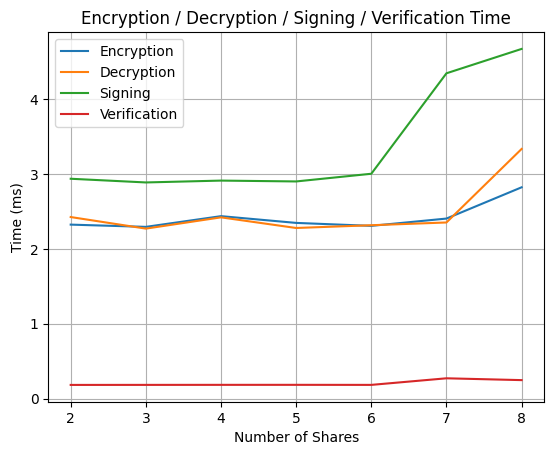

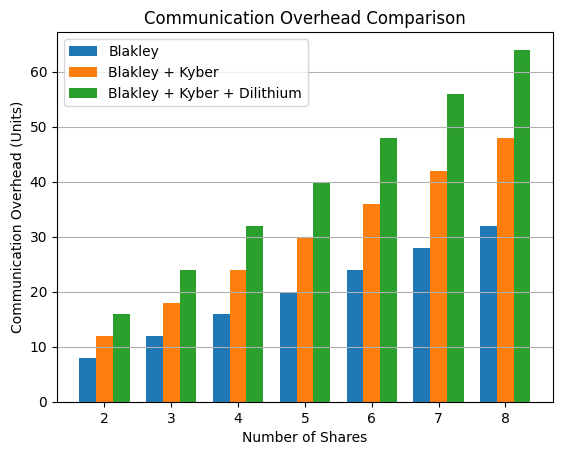

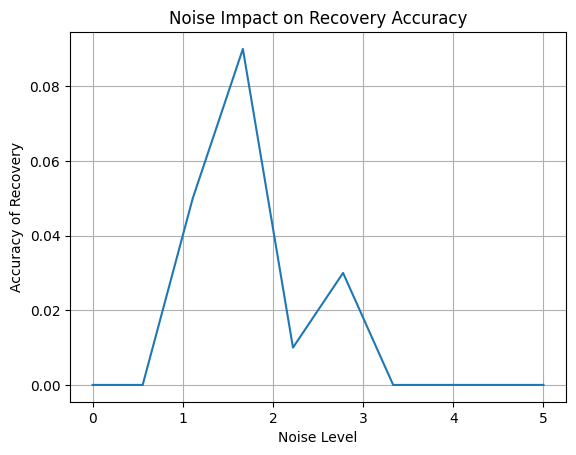

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import time
import random

# -----------------------------
# SIMULATION PARAMETERS
# -----------------------------
q = 17
share_sizes = [2, 3, 4, 5, 6, 7, 8]

enc_times = []
dec_times = []
sign_times = []
verify_times = []

# -----------------------------
# SIMULATE PERFORMANCE
# -----------------------------
for n in share_sizes:
    m = np.random.randint(1, 10, size=4)

    # ---- Encryption ----
    start = time.time()
    for _ in range(1000):
        k = random.randint(1, 10)
        v = (m + k) % q
    enc_times.append((time.time() - start) * 1000)

    # ---- Decryption ----
    start = time.time()
    for _ in range(1000):
        k = random.randint(1, 10)
        m_prime = (v - k) % q
    dec_times.append((time.time() - start) * 1000)

    # ---- Signing ----
    start = time.time()
    for _ in range(1000):
        H = np.sum(m) % q
        sigma = (H * 2) % q
    sign_times.append((time.time() - start) * 1000)

    # ---- Verification ----
    start = time.time()
    for _ in range(1000):
        check = (H * 4) % q
    verify_times.append((time.time() - start) * 1000)

# -----------------------------
# GRAPH 1: TIME PERFORMANCE
# -----------------------------
plt.figure()
plt.plot(share_sizes, enc_times)
plt.plot(share_sizes, dec_times)
plt.plot(share_sizes, sign_times)
plt.plot(share_sizes, verify_times)

plt.xlabel("Number of Shares")
plt.ylabel("Time (ms)")
plt.title("Encryption / Decryption / Signing / Verification Time")
plt.legend(["Encryption", "Decryption", "Signing", "Verification"])
plt.grid()
plt.show()


# -----------------------------
# GRAPH 2: COMMUNICATION OVERHEAD (BAR GRAPH)
# -----------------------------
import numpy as np
import matplotlib.pyplot as plt

shares = np.array(share_sizes)

# Simulated overhead units
blakley = shares * 4
kyber = shares * 6
dilithium = shares * 8

x = np.arange(len(shares))
width = 0.25

plt.figure()

plt.bar(x - width, blakley, width, label="Blakley")
plt.bar(x, kyber, width, label="Blakley + Kyber")
plt.bar(x + width, dilithium, width, label="Blakley + Kyber + Dilithium")

plt.xlabel("Number of Shares")
plt.ylabel("Communication Overhead (Units)")
plt.title("Communication Overhead Comparison")

plt.xticks(x, shares)
plt.legend()
plt.grid(axis='y')

plt.show()


# -----------------------------
# GRAPH 3: NOISE vs ACCURACY
# -----------------------------
noise_levels = np.linspace(0, 5, 10)
accuracy = []

for noise in noise_levels:
    correct = 0
    trials = 100

    for _ in range(trials):
        m = np.array([2, 1, 3, 5])
        noisy = m + np.random.randint(0, int(noise)+1, size=4)

        # median rule
        median = np.sort(noisy)[len(noisy)//2]
        count = np.sum(noisy >= median)

        if count >= len(noisy)/2:
            corrected = noisy - 1
        else:
            corrected = noisy

        if np.all(corrected == m):
            correct += 1

    accuracy.append(correct / trials)

plt.figure()
plt.plot(noise_levels, accuracy)

plt.xlabel("Noise Level")
plt.ylabel("Accuracy of Recovery")
plt.title("Noise Impact on Recovery Accuracy")
plt.grid()
plt.show()